# 05 – Extract Frame Features NTHU

Tujuan:
Mengekstrak vektor 512-dim untuk setiap gambar dalam dataset NTHUDDD2 menggunakan ke-4 backbone yang sudah disiapkan di Tahap 1.

Fitur ini akan disimpan ke dalam file `.pt` (PyTorch Tensor) untuk mempercepat proses windowing dan training LSTM di tahap selanjutnya.


# Import dan Setup Awal

In [ ]:
# 1. IMPORT & KONFIGURASI DASAR
import os
import gc
import torch
from torch import nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import timm
import re
from collections import defaultdict


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

# ─── PATH ───────────────────────────────────────────────────────────────────
BASE_DIR           = r"C:\kuliah-sementara\SKRIPSI"
DATASET_NTHU_SPLIT = os.path.join(BASE_DIR, "Dataset_nthuddd2_eye_SPLIT")
MODELS_MRL_DIR     = os.path.join(BASE_DIR, "models_saved_data_MRL")
FEATURES_NTHU_DIR  = os.path.join(BASE_DIR, "features_nthuddd2")
os.makedirs(FEATURES_NTHU_DIR, exist_ok=True)

# ─── NORMALISASI (statistik MRL — disengaja untuk domain alignment) ──────────
IMG_MEAN = [0.3772, 0.3772, 0.3772]
IMG_STD  = [0.1544, 0.1544, 0.1544]
IMG_SIZE = 224

extract_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

# ─── PATH .pth TIAP MODEL (PERBAIKAN: eksplisit & konsisten) ─────────────────
MODEL_PTH_PATHS = {
    "CNN_BASIC": os.path.join(MODELS_MRL_DIR, "CNN_BASIC", "CNN_BASIC_BEST.pth"),
    "MOBILENET": os.path.join(MODELS_MRL_DIR, "MOBILENET", "MOBILENET_BEST.pth"),
    "VGG19":     os.path.join(MODELS_MRL_DIR, "VGG19",     "VGG19_BEST.pth"),
    "SWIN":      os.path.join(MODELS_MRL_DIR, "SWIN",      "SWIN_BEST.pth"),
}

# Verifikasi semua .pth ada sebelum memulai proses panjang
print("\nVerifikasi path model:")
for name, path in MODEL_PTH_PATHS.items():
    status = "[OK]" if os.path.exists(path) else "[TIDAK ADA!]"
    print(f"  {status} {name}: {path}")

Device in use: cuda

Verifikasi path model:
  [OK] CNN_BASIC: C:\kuliah-sementara\SKRIPSI\models_saved_data_MRL\CNN_BASIC\CNN_BASIC_BEST.pth
  [OK] MOBILENET: C:\kuliah-sementara\SKRIPSI\models_saved_data_MRL\MOBILENET\MOBILENET_BEST.pth
  [OK] VGG19: C:\kuliah-sementara\SKRIPSI\models_saved_data_MRL\VGG19\VGG19_BEST.pth
  [OK] SWIN: C:\kuliah-sementara\SKRIPSI\models_saved_data_MRL\SWIN\SWIN_BEST.pth


# Fungsi Custom Dataset + Validasi Urutan Temporal

In [ ]:
def natural_sort_key(path: str) -> list:
    """
    Kunci sorting natural (numerik) untuk nama file.

    Masalah:  "frame_10.jpg" < "frame_2.jpg" secara alfabet → urutan kacau
    Solusi:   Pisahkan angka dari teks → bandingkan sebagai integer

    Contoh hasil:
        frame_1.jpg  → ['frame_', 1, '.jpg']
        frame_2.jpg  → ['frame_', 2, '.jpg']
        frame_10.jpg → ['frame_', 10, '.jpg']
    Sehingga: frame_1 < frame_2 < frame_10  ✓
    """
    basename = os.path.basename(path)
    parts    = re.split(r'(\d+)', basename)          
    return [int(p) if p.isdigit() else p.lower() for p in parts]


class SortedImageFolder(datasets.ImageFolder):
    """
    ImageFolder yang mengganti urutan default (string alfabet)
    dengan urutan natural sort (numerik).

    Kenapa subclass, bukan custom dari nol?
    Karena ImageFolder sudah menangani:
    - Mapping kelas ke integer label
    - Pembacaan gambar dan transform
    Kita hanya perlu mengganti urutan samples & imgs.
    """
    def __init__(self, root, transform=None):
        super().__init__(root=root, transform=transform)

        # Ganti urutan: sort berdasarkan path dengan natural sort key
        self.samples = sorted(self.samples, key=lambda x: natural_sort_key(x[0]))
        self.imgs    = self.samples  # imgs adalah alias untuk samples di ImageFolder


def validate_temporal_order(dataset: SortedImageFolder):
    """
    Cetak 5 file pertama & terakhir per kelas agar
    kamu bisa verifikasi urutan secara visual.
    Juga deteksi otomatis kalau urutan masih kacau.
    """
    print("\n[VALIDASI URUTAN TEMPORAL]")

    per_class = defaultdict(list)
    for path, label in dataset.samples:
        per_class[dataset.classes[label]].append(os.path.basename(path))

    for cls, files in per_class.items():
        print(f"\n  Kelas '{cls}' — {len(files):,} file")
        print(f"  5 Pertama : {files[:5]}")
        print(f"  5 Terakhir: {files[-5:]}")

        # Ambil angka dari 20 file pertama → cek apakah sudah terurut naik
        nums = []
        for f in files[:20]:
            m = re.search(r'\d+', f)          # ← BENAR: r'\d+' bukan r'\\d+'
            if m:
                nums.append(int(m.group()))

        if nums and nums != sorted(nums):
            print(f"  ⚠ WARNING: Urutan TIDAK numerik! Ditemukan: {nums[:10]}")
        else:
            print(f"  ✓ Urutan numerik terverifikasi.")

# Definisi Arsitektur

In [3]:
# 2. DEFINISI ARSITEKTUR BACKBONE DENGAN return_features=True

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.gap(self.features(x))
        x = self.classifier[0](x)
        features_512 = self.classifier[3](self.classifier[2](self.classifier[1](x)))
        if return_features:
            return features_512
        return self.classifier[4](features_512)


class MobileNetDrowsiness(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.mobilenet_v3_small(weights=None)
        self.features = base.features
        self.avgpool  = base.avgpool
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(base.classifier[0].in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, return_features=False):
        x = torch.flatten(self.avgpool(self.features(x)), 1)
        features_512 = self.classifier[3](self.classifier[2](self.classifier[1](self.classifier[0](x))))
        if return_features:
            return features_512
        return self.classifier[4](features_512)


class VGG19Drowsiness(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.vgg19_bn(weights=None)
        self.features  = base.features
        self.avgpool   = base.avgpool
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(base.classifier[0].in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, return_features=False):
        x = torch.flatten(self.avgpool(self.features(x)), 1)
        features_512 = self.classifier[3](self.classifier[2](self.classifier[1](self.classifier[0](x))))
        if return_features:
            return features_512
        return self.classifier[4](features_512)


class SwinDrowsiness(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(self.backbone.num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)
        features_512 = self.classifier[3](self.classifier[2](self.classifier[1](self.classifier[0](x))))
        if return_features:
            return features_512
        return self.classifier[4](features_512)

#  Load Model + Verifikasi strict=False

In [4]:
# 3. LOAD MODEL + VERIFIKASI KEY YANG MISSING/UNEXPECTED

def load_pretrained_model(model_name: str):
    """
    Load bobot .pth dari training MRL ke arsitektur yang sudah didefinisikan.
    Menampilkan laporan key missing/unexpected agar kamu yakin bobot ter-load.
    """
    model_map = {
        "CNN_BASIC": SimpleCNN,
        "MOBILENET": MobileNetDrowsiness,
        "VGG19":     VGG19Drowsiness,
        "SWIN":      SwinDrowsiness,
    }

    assert model_name in model_map, f"Model '{model_name}' tidak dikenali."
    model = model_map[model_name](num_classes=2)

    pth_path = MODEL_PTH_PATHS[model_name]
    assert os.path.exists(pth_path), f"File .pth tidak ditemukan: {pth_path}"

    state = torch.load(pth_path, map_location="cpu")
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]

    # Hapus prefix "model." jika ada (artifact dari training lama)
    state = {
        (k.replace("model.", "", 1) if k.startswith("model.") else k): v
        for k, v in state.items()
    }

    # ── PERBAIKAN: Gunakan load_state_dict dengan strict=True dulu untuk deteksi masalah ──
    # Kemudian fallback ke strict=False dengan laporan lengkap
    result = model.load_state_dict(state, strict=False)

    # Laporan verifikasi — INI YANG SEBELUMNYA TIDAK ADA
    missing  = result.missing_keys    # key di arsitektur tapi tidak ada di .pth
    unexp    = result.unexpected_keys  # key di .pth tapi tidak ada di arsitektur

    print(f"\n[{model_name}] Laporan Load State Dict:")
    if not missing and not unexp:
        print("  ✓ Semua key cocok sempurna (tidak ada missing/unexpected).")
    else:
        if missing:
            print(f"  ⚠ Missing keys ({len(missing)}): {missing[:5]}{'...' if len(missing)>5 else ''}")
        if unexp:
            print(f"  ⚠ Unexpected keys ({len(unexp)}): {unexp[:5]}{'...' if len(unexp)>5 else ''}")

    # Freeze semua parameter
    for p in model.parameters():
        p.requires_grad = False

    # Verifikasi freeze berhasil
    trainable = sum(p.requires_grad for p in model.parameters())
    print(f"  ✓ Trainable params setelah freeze: {trainable} (harus 0)")

    return model.to(device).eval()

#  Fungsi Ekstraksi (PERBAIKAN: nama folder konsisten + tambah path info)

In [5]:
def extract_features_to_disk(model, model_name: str, split_name: str):
    
    save_dir = os.path.join(FEATURES_NTHU_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)

    data_dir = os.path.join(DATASET_NTHU_SPLIT, split_name)

    # PERBAIKAN UTAMA: Gunakan SortedImageFolder, bukan ImageFolder biasa
    dataset = SortedImageFolder(root=data_dir, transform=extract_transform)
    
    # Validasi urutan — jalankan hanya sekali (untuk model pertama saja)
    if model_name == "CNN_BASIC":
        validate_temporal_order(dataset)

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,   
        num_workers=0,
        pin_memory=True,
    )

    all_features = []
    all_labels   = []
    all_paths    = [path for path, _ in dataset.samples]

    print(f"\n{model_name} — Ekstraksi {split_name.upper()} | {len(dataset):,} gambar")

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Extract {split_name}"):
            images = images.to(device)
            feats  = model(images, return_features=True)
            all_features.append(feats.cpu())
            all_labels.append(labels.cpu())

    final_features = torch.cat(all_features, dim=0)
    final_labels   = torch.cat(all_labels,   dim=0)

    save_name = f"{model_name}_Features_{split_name.capitalize()}_NTHUD.pt"
    save_path = os.path.join(save_dir, save_name)

    torch.save({
        "features": final_features,
        "labels":   final_labels,
        "paths":    all_paths,
        "model":    model_name,
        "split":    split_name,
        "img_mean": IMG_MEAN,
        "img_std":  IMG_STD,
        "sorted":   True,   # [BARU] flag eksplisit — notebook LSTM bisa cek ini
    }, save_path)

    print(f"  ✓ Tersimpan: {save_path} | Shape: {final_features.shape}")

    if torch.isnan(final_features).any() or torch.isinf(final_features).any():
        print(f"  ⚠ WARNING: Ditemukan NaN/Inf!")
    else:
        print(f"  ✓ Tidak ada NaN/Inf.")

#  Eksekusi Semua Model & Split 

In [6]:
# 5. EKSEKUSI EKSTRAKSI FITUR — SEMUA MODEL & SPLIT

MODELS_TO_EXTRACT = ["CNN_BASIC", "MOBILENET", "VGG19", "SWIN"]
SPLITS            = ["train", "val", "test"]

for mname in MODELS_TO_EXTRACT:
    print(f"\n{'='*60}")
    print(f"  Load Model: {mname}")
    print(f"{'='*60}")

    model = load_pretrained_model(mname)

    for split in SPLITS:
        extract_features_to_disk(model, mname, split)

    # Bersihkan memori GPU sebelum load model berikutnya
    del model
    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("  SEMUA EKSTRAKSI SELESAI")
print("="*60)


  Load Model: CNN_BASIC

[CNN_BASIC] Laporan Load State Dict:
  ✓ Semua key cocok sempurna (tidak ada missing/unexpected).
  ✓ Trainable params setelah freeze: 0 (harus 0)

[VALIDASI URUTAN TEMPORAL]

  Kelas 'notdrowsy' — 35,946 file
  5 Pertama : ['001_glasses_nonsleepyCombination_0_notdrowsy_L.jpg', '001_glasses_nonsleepyCombination_0_notdrowsy_R.jpg', '001_glasses_nonsleepyCombination_1_notdrowsy_L.jpg', '001_glasses_nonsleepyCombination_1_notdrowsy_R.jpg', '001_glasses_nonsleepyCombination_2_notdrowsy_L.jpg']
  5 Terakhir: ['005_noglasses_yawning_1746_notdrowsy_R.jpg', '005_noglasses_yawning_1747_notdrowsy_L.jpg', '005_noglasses_yawning_1747_notdrowsy_R.jpg', '005_noglasses_yawning_1748_notdrowsy_L.jpg', '005_noglasses_yawning_1748_notdrowsy_R.jpg']
  ✓ Urutan numerik terverifikasi.

  Kelas 'drowsy' — 45,324 file
  5 Pertama : ['001_glasses_sleepyCombination_599_drowsy_L.jpg', '001_glasses_sleepyCombination_599_drowsy_R.jpg', '001_glasses_sleepyCombination_600_drowsy_L.jpg', '00

Extract train:   0%|          | 0/635 [00:00<?, ?it/s]

  ✓ Tersimpan: C:\kuliah-sementara\SKRIPSI\features_nthuddd2\CNN_BASIC\CNN_BASIC_Features_Train_NTHUD.pt | Shape: torch.Size([81270, 512])
  ✓ Tidak ada NaN/Inf.

[VALIDASI URUTAN TEMPORAL]

  Kelas 'notdrowsy' — 15,542 file
  5 Pertama : ['002_glasses_nonsleepyCombination_0_notdrowsy_L.jpg', '002_glasses_nonsleepyCombination_0_notdrowsy_R.jpg', '002_glasses_nonsleepyCombination_1_notdrowsy_L.jpg', '002_glasses_nonsleepyCombination_1_notdrowsy_R.jpg', '002_glasses_nonsleepyCombination_2_notdrowsy_L.jpg']
  5 Terakhir: ['002_noglasses_yawning_1485_notdrowsy_R.jpg', '002_noglasses_yawning_1486_notdrowsy_L.jpg', '002_noglasses_yawning_1486_notdrowsy_R.jpg', '002_noglasses_yawning_1487_notdrowsy_L.jpg', '002_noglasses_yawning_1487_notdrowsy_R.jpg']
  ✓ Urutan numerik terverifikasi.

  Kelas 'drowsy' — 21,192 file
  5 Pertama : ['002_glasses_sleepyCombination_314_drowsy_L.jpg', '002_glasses_sleepyCombination_314_drowsy_R.jpg', '002_glasses_sleepyCombination_315_drowsy_L.jpg', '002_glasses_s

Extract val:   0%|          | 0/287 [00:00<?, ?it/s]

  ✓ Tersimpan: C:\kuliah-sementara\SKRIPSI\features_nthuddd2\CNN_BASIC\CNN_BASIC_Features_Val_NTHUD.pt | Shape: torch.Size([36734, 512])
  ✓ Tidak ada NaN/Inf.

[VALIDASI URUTAN TEMPORAL]

  Kelas 'notdrowsy' — 7,649 file
  5 Pertama : ['006_glasses_nonsleepyCombination_0_notdrowsy_L.jpg', '006_glasses_nonsleepyCombination_0_notdrowsy_R.jpg', '006_glasses_nonsleepyCombination_1_notdrowsy_L.jpg', '006_glasses_nonsleepyCombination_1_notdrowsy_R.jpg', '006_glasses_nonsleepyCombination_2_notdrowsy_L.jpg']
  5 Terakhir: ['006_glasses_slowBlinkWithNodding_1019_notdrowsy_R.jpg', '006_glasses_slowBlinkWithNodding_1020_notdrowsy_L.jpg', '006_glasses_slowBlinkWithNodding_1020_notdrowsy_R.jpg', '006_glasses_slowBlinkWithNodding_1021_notdrowsy_L.jpg', '006_glasses_slowBlinkWithNodding_1021_notdrowsy_R.jpg']
  ✓ Urutan numerik terverifikasi.

  Kelas 'drowsy' — 5,534 file
  5 Pertama : ['006_glasses_sleepyCombination_128_drowsy - Copy_L.jpg', '006_glasses_sleepyCombination_128_drowsy - Copy_R.jpg',

...

  ✓ Tersimpan: C:\kuliah-sementara\SKRIPSI\features_nthuddd2\SWIN\SWIN_Features_Train_NTHUD.pt | Shape: torch.Size([81270, 512])
  ✓ Tidak ada NaN/Inf.

SWIN — Ekstraksi VAL | 36,734 gambar


Extract val:   0%|          | 0/287 [00:00<?, ?it/s]

  ✓ Tersimpan: C:\kuliah-sementara\SKRIPSI\features_nthuddd2\SWIN\SWIN_Features_Val_NTHUD.pt | Shape: torch.Size([36734, 512])
  ✓ Tidak ada NaN/Inf.

SWIN — Ekstraksi TEST | 13,183 gambar


Extract test:   0%|          | 0/103 [00:00<?, ?it/s]

  ✓ Tersimpan: C:\kuliah-sementara\SKRIPSI\features_nthuddd2\SWIN\SWIN_Features_Test_NTHUD.pt | Shape: torch.Size([13183, 512])
  ✓ Tidak ada NaN/Inf.

  SEMUA EKSTRAKSI SELESAI


# Verifikasi Struktur Folder Output

In [7]:
# 6. [BARU] VERIFIKASI STRUKTUR OUTPUT & ESTIMASI UNTUK LSTM

print("="*60)
print("VERIFIKASI HASIL EKSTRAKSI FITUR")
print("="*60)

WINDOW_SIZE = 30  # titik awal — bisa disesuaikan berdasarkan analisis 05

total_sequences = 0

for mname in MODELS_TO_EXTRACT:
    print(f"\n[{mname}]")
    model_dir = os.path.join(FEATURES_NTHU_DIR, mname)

    for split in SPLITS:
        fpath = os.path.join(model_dir, f"{mname}_Features_{split.capitalize()}_NTHUD.pt")

        if not os.path.exists(fpath):
            print(f"  ⚠ TIDAK ADA: {fpath}")
            continue

        data = torch.load(fpath, map_location="cpu")
        N    = data["features"].shape[0]
        est_seq = max(0, N - WINDOW_SIZE + 1)  # estimasi kasar sekuens sliding window

        print(f"  {split:<6}: {N:>7,} frame  →  ~{est_seq:>7,} sekuens LSTM "
              f"(window={WINDOW_SIZE})")
        total_sequences += est_seq

print(f"\n  Estimasi total sekuens LSTM (semua split, semua model): ~{total_sequences:,}")
print("\n[INFO] Angka ini belum mempertimbangkan batas antar-subjek/video.")
print("       Pastikan windowing di notebook berikutnya TIDAK melewati batas video.")

VERIFIKASI HASIL EKSTRAKSI FITUR

[CNN_BASIC]
  train :  81,270 frame  →  ~ 81,241 sekuens LSTM (window=30)
  val   :  36,734 frame  →  ~ 36,705 sekuens LSTM (window=30)
  test  :  13,183 frame  →  ~ 13,154 sekuens LSTM (window=30)

[MOBILENET]
  train :  81,270 frame  →  ~ 81,241 sekuens LSTM (window=30)
  val   :  36,734 frame  →  ~ 36,705 sekuens LSTM (window=30)
  test  :  13,183 frame  →  ~ 13,154 sekuens LSTM (window=30)

[VGG19]
  train :  81,270 frame  →  ~ 81,241 sekuens LSTM (window=30)
  val   :  36,734 frame  →  ~ 36,705 sekuens LSTM (window=30)
  test  :  13,183 frame  →  ~ 13,154 sekuens LSTM (window=30)

[SWIN]
  train :  81,270 frame  →  ~ 81,241 sekuens LSTM (window=30)
  val   :  36,734 frame  →  ~ 36,705 sekuens LSTM (window=30)
  test  :  13,183 frame  →  ~ 13,154 sekuens LSTM (window=30)

  Estimasi total sekuens LSTM (semua split, semua model): ~524,400

[INFO] Angka ini belum mempertimbangkan batas antar-subjek/video.
       Pastikan windowing di notebook berikut

C:\Users\USER\AppData\Local\Temp\ipykernel_3848\1834103351.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, facecolor=SURFACE, edgecolor=BORDER,
C:\Users\USER\AppData\Local\Temp\ipykernel_3848\1834103351.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, facecolor=SURFACE, edgecolor=BORDER,
C:\Users\USER\AppData\Local\Temp\ipykernel_3848\1834103351.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, facecolor=SURFACE, edgecolor=BORDER,


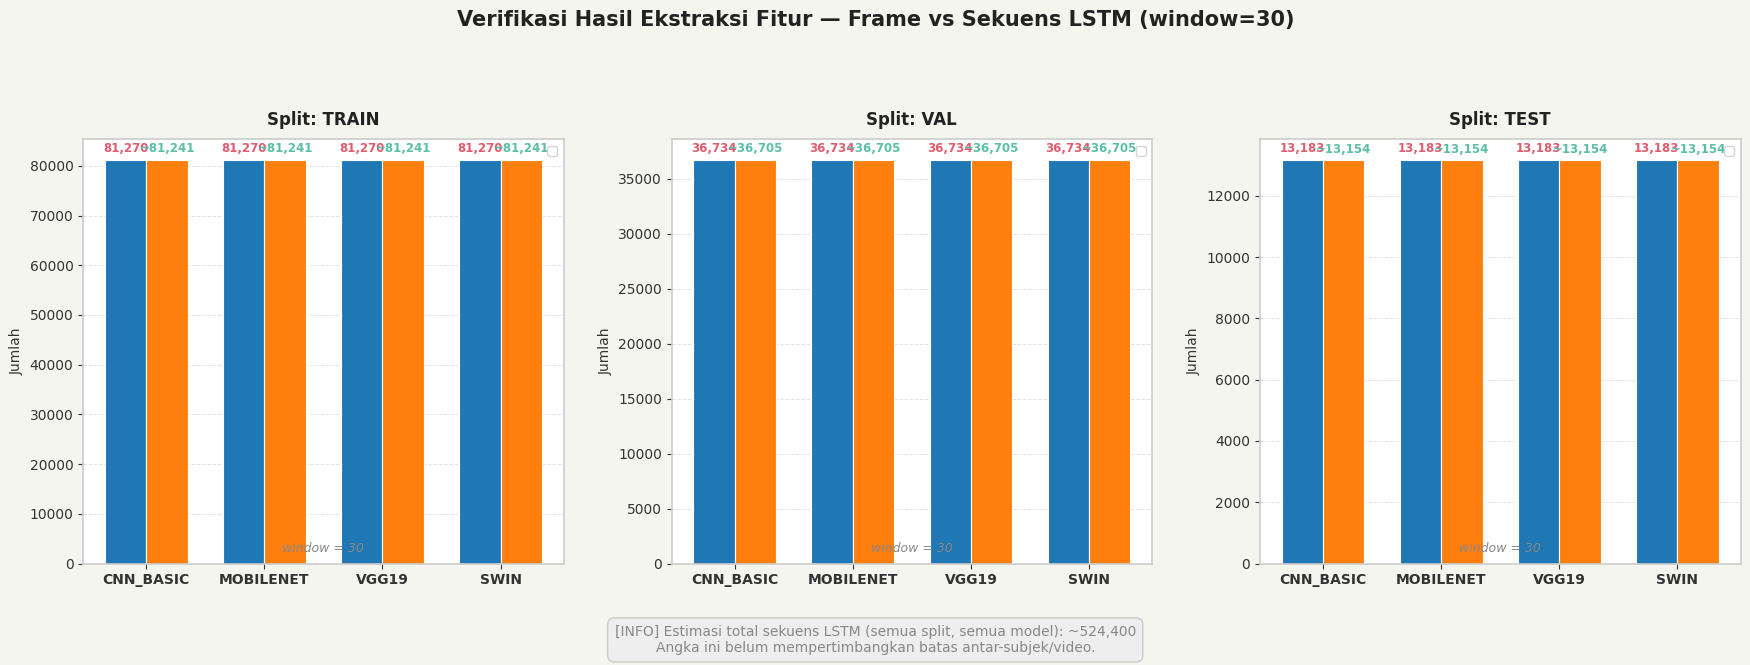

✅ Saved: verifikasi_ekstraksi_fitur.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
# DATA
# ============================================================
models = ['CNN_BASIC', 'MOBILENET', 'VGG19', 'SWIN']
splits = ['train', 'val', 'test']

frames = {
    'train': 81270,
    'val':   36734,
    'test':  13183,
}
sequences = {
    'train': 81241,
    'val':   36705,
    'test':  13154,
}

# ============================================================
# WARNA — light theme sesuai referensi gambar
# ============================================================
BG        = '#f5f5f0'   # background utama putih keabuan
SURFACE   = '#ffffff'   # background panel
BORDER    = '#cccccc'   # border tipis abu
TEXT      = '#333333'   # teks utama gelap
TITLE     = '#222222'   # judul
DIM       = '#888888'   # teks redup / info
C_FRAME   = '#e05c6e'   # merah muda — Frame
C_SEQ     = '#5bbfa8'   # teal hijau — Sekuens LSTM

x     = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Verifikasi Hasil Ekstraksi Fitur — Frame vs Sekuens LSTM (window=30)',
             fontsize=15, fontweight='bold', color=TITLE, y=1.02)

split_labels_display = {'train': 'TRAIN', 'val': 'VAL', 'test': 'TEST'}

def style_ax(ax, title):
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(1.2)
    ax.tick_params(colors=TEXT, labelsize=10)
    ax.set_title(title, color=TITLE, fontsize=12, fontweight='bold', pad=10)
    ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.7, linestyle='--', alpha=0.9)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10, color=TEXT, fontweight='bold')
    ax.yaxis.label.set_color(TEXT)

for i, split in enumerate(splits):
    ax = axes[i]

    frame_val = frames[split]
    seq_val   = sequences[split]

    frame_vals = [frame_val] * len(models)
    seq_vals   = [seq_val]   * len(models)

    bars1 = ax.bar(x - width/2, frame_vals, width,
                   edgecolor='white', linewidth=0.8)
    bars2 = ax.bar(x + width/2, seq_vals, width,
                   edgecolor='white', linewidth=0.8)

    style_ax(ax, f'Split: {split_labels_display[split]}')
    ax.set_ylabel('Jumlah', fontsize=10, color=TEXT)

    max_val = max(frame_val, seq_val)
    offset  = max_val * 0.012

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f'{bar.get_height():,}',
                ha='center', va='bottom',
                fontsize=8.5, color=C_FRAME, fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f'~{bar.get_height():,}',
                ha='center', va='bottom',
                fontsize=8.5, color=C_SEQ, fontweight='bold')

    ax.legend(fontsize=9, facecolor=SURFACE, edgecolor=BORDER,
              labelcolor=TEXT, loc='upper right')

    ax.text(0.5, 0.02,
            'window = 30',
            ha='center', va='bottom',
            transform=ax.transAxes,
            fontsize=9, color=DIM, style='italic')

# ── Footer info ───────────────────────────────────────────────
fig.text(0.5, -0.05,
         '[INFO] Estimasi total sekuens LSTM (semua split, semua model): ~524,400\n'
         'Angka ini belum mempertimbangkan batas antar-subjek/video.',
         ha='center', fontsize=10, color=DIM,
         bbox=dict(facecolor='#eeeeee', edgecolor=BORDER,
                   boxstyle='round,pad=0.5'))

# ============================================================
# SAVE
# ============================================================
plt.tight_layout(pad=2.5)
plt.savefig('verifikasi_ekstraksi_fitur.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("✅ Saved: verifikasi_ekstraksi_fitur.png")